In [23]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, models, transforms
from torch.utils.data import DataLoader
import os

import matplotlib.pyplot as plt


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
if torch.cuda.is_available():
   
    torch.backends.cudnn.benchmark = True
    print(f"CUDA Version: {torch.version.cuda}")
    print(f"GPU Device: {torch.cuda.get_device_name(0)}")
else:
    print("GPU not found.")

CUDA Version: 12.6
GPU Device: Tesla T4


In [24]:

data_dir = '/kaggle/input/datasets/msambare/fer2013' 

data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10), 
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'test': transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms[x]) for x in ['train', 'test']}


dataloaders = {
    x: DataLoader(image_datasets[x], batch_size=64, shuffle=True, 
                  num_workers=2, pin_memory=True) 
    for x in ['train', 'test']
}

class_names = image_datasets['train'].classes
print(f"Classes: {class_names}")

Classes: ['angry', 'disgust', 'fear', 'happy', 'neutral', 'sad', 'surprise']


In [25]:

model = models.resnet18(weights='IMAGENET1K_V1')


num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, 7) 

model = model.to(device)

In [26]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.AdamW(model.parameters(), lr=1e-4, weight_decay=0.01)


epochs = 15
scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer, max_lr=1e-3, 
    steps_per_epoch=len(dataloaders['train']), 
    epochs=epochs
)

In [27]:
from torch.amp import GradScaler, autocast

def train_model(model, criterion, optimizer, scheduler, num_epochs=15):
    scaler = GradScaler('cuda')
   
    total_steps_limit = epochs * len(dataloaders['train'])
    current_step = 0

    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        
        for phase in ['train', 'test']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss, running_corrects = 0.0, 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    with autocast('cuda'):
                        outputs = model(inputs)
                        _, preds = torch.max(outputs, 1)
                        loss = criterion(outputs, labels)

                    if phase == 'train':
                        scaler.scale(loss).backward()
                        scaler.step(optimizer)
                        scaler.update()
                        
                       
                        if current_step < total_steps_limit:
                            scheduler.step()
                            current_step += 1

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)

            epoch_loss = running_loss / len(image_datasets[phase])
            epoch_acc = running_corrects.double() / len(image_datasets[phase])
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')

    return model

model = train_model(model, criterion, optimizer, scheduler, num_epochs=epochs)

Epoch 1/15
train Loss: 1.2369 Acc: 0.5301
test Loss: 1.0611 Acc: 0.5984
Epoch 2/15
train Loss: 1.0224 Acc: 0.6168
test Loss: 1.0621 Acc: 0.6081
Epoch 3/15
train Loss: 0.9873 Acc: 0.6285
test Loss: 1.0404 Acc: 0.6091
Epoch 4/15
train Loss: 0.9640 Acc: 0.6396
test Loss: 0.9971 Acc: 0.6229
Epoch 5/15
train Loss: 0.9164 Acc: 0.6585
test Loss: 1.0444 Acc: 0.6216
Epoch 6/15
train Loss: 0.8617 Acc: 0.6770
test Loss: 1.0283 Acc: 0.6276
Epoch 7/15
train Loss: 0.8128 Acc: 0.6973
test Loss: 0.9546 Acc: 0.6602
Epoch 8/15
train Loss: 0.7514 Acc: 0.7191
test Loss: 0.9245 Acc: 0.6624
Epoch 9/15
train Loss: 0.6743 Acc: 0.7493
test Loss: 0.9925 Acc: 0.6489
Epoch 10/15
train Loss: 0.5799 Acc: 0.7862
test Loss: 0.9636 Acc: 0.6658
Epoch 11/15
train Loss: 0.4640 Acc: 0.8309
test Loss: 0.9663 Acc: 0.6760
Epoch 12/15
train Loss: 0.3351 Acc: 0.8840
test Loss: 1.0758 Acc: 0.6920
Epoch 13/15
train Loss: 0.2347 Acc: 0.9207
test Loss: 1.1400 Acc: 0.6974
Epoch 14/15
train Loss: 0.1639 Acc: 0.9455
test Loss: 1.1863

In [28]:
torch.save(model.state_dict(), 'resnet18_fer2013_optimized.pth')
print("Optimized model saved!")

Optimized model saved!


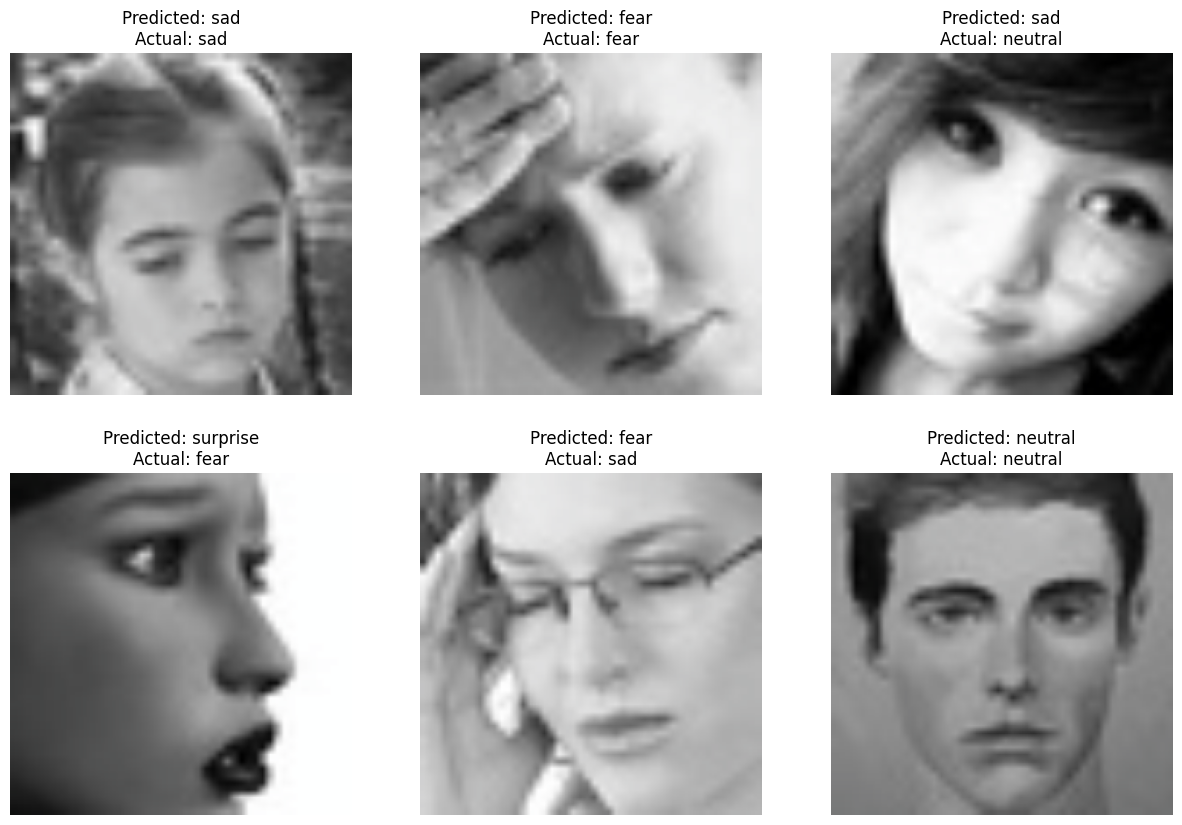

In [30]:
import matplotlib.pyplot as plt
import torch

def visualize_model_predictions(model, num_images=6):
    was_training = model.training
    model.eval()
    images_so_far = 0
    plt.figure(figsize=(15, 10))

    with torch.no_grad():
        for i, (inputs, labels) in enumerate(dataloaders['test']):
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)

            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(num_images // 3, 3, images_so_far)
                ax.axis('off')
                ax.set_title(f'Predicted: {class_names[preds[j]]}\nActual: {class_names[labels[j]]}')
                
                
                img = inputs.cpu().data[j].numpy().transpose((1, 2, 0))
                import numpy as np
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)
                plt.imshow(img)

                if images_so_far == num_images:
                    model.train(mode=was_training)
                    return
        model.train(mode=was_training)


visualize_model_predictions(model)